In [24]:
from matrix import*  
from solver import* 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3
#ped
numped = 1
pedmass = 70     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

#mat=np.zeros(1,numped) #to be extended into probabilistic inputs
mped=np.array([pedmass])
cped = np.array([cped])
kped = np.array([kped])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)

u,du,ddu_hsi = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,kped,cped,xrb,linearMass)
           

[[ 0.00000000e+00  7.59910994e-03  1.49506805e-02 ... -2.34905852e+01
  -1.23290854e+01  0.00000000e+00]
 [ 0.00000000e+00  1.43267986e-02  2.49656911e-02 ... -8.95719573e-02
  -3.08025191e-01  0.00000000e+00]
 [ 0.00000000e+00  1.72133652e-02  1.73327240e-02 ... -7.08459606e-03
  -1.10721202e-02  0.00000000e+00]
 [ 0.00000000e+00  2.46859918e-08  1.71597852e-07 ... -2.05025114e-03
  -1.93004580e-03  0.00000000e+00]]


In [25]:
     
accn_hsi = accdyn_super(Bridge,ddu_hsi,x_interested,hht)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)



[[ 0.00000000e+00  7.59910996e-03  1.49506807e-02 ... -1.76004411e+01
  -1.14039278e+00  0.00000000e+00]
 [ 0.00000000e+00  1.43267986e-02  2.49656914e-02 ... -9.12730129e-02
  -3.08833738e-01  0.00000000e+00]
 [ 0.00000000e+00  1.72133652e-02  1.73327243e-02 ... -7.10422223e-03
  -1.10966198e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


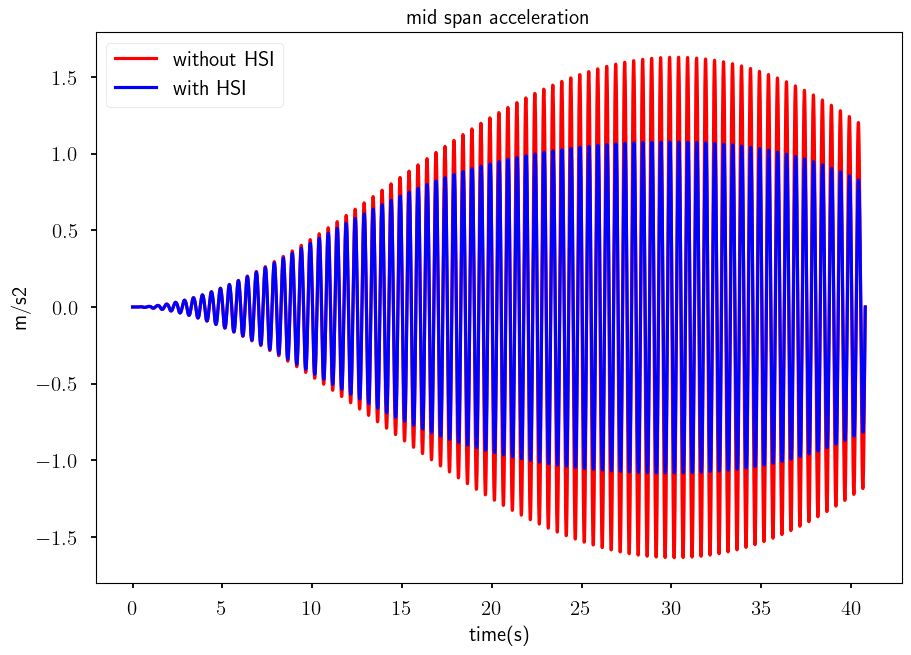

Maximum acceleration: 1.0754472458910813 m/s² at time 29.91 s with HSI
Maximum acceleration: 1.6278474023092573 m/s² at time 30.400000000000002 s bwithout HSI


In [26]:


u,du,ddu = Newmarksuper_HSI (Human,Bridge,numped,numbers,length,hht,pedvelocity,[1],[0],[0],xrb,linearMass)
                
accn = accdyn_super(Bridge,ddu,x_interested,hht)

t = np.arange(0, (length+1) / pedvelocity, hht)
plt.plot(t,accn , label ="without HSI" ,color='r')
plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)

# Find the index of the maximum value in accn
max_index_accn = np.argmax(accn_hsi)

# Find the maximum value
max_accn_hsi = accn_hsi[max_index_accn]

# Find the corresponding time
max_time_accn_hsi = t[max_index_accn]

# Print the results
print(f"Maximum acceleration: {max_accn_hsi} m/s² at time {max_time_accn_hsi} s with HSI")

# Find the index of the maximum value in accn
max_index_accn = np.argmax(accn)

# Find the maximum value
max_accn = accn[max_index_accn]

# Find the corresponding time
max_time_accn = t[max_index_accn]

# Print the results
print(f"Maximum acceleration: {max_accn} m/s² at time {max_time_accn} s bwithout HSI")



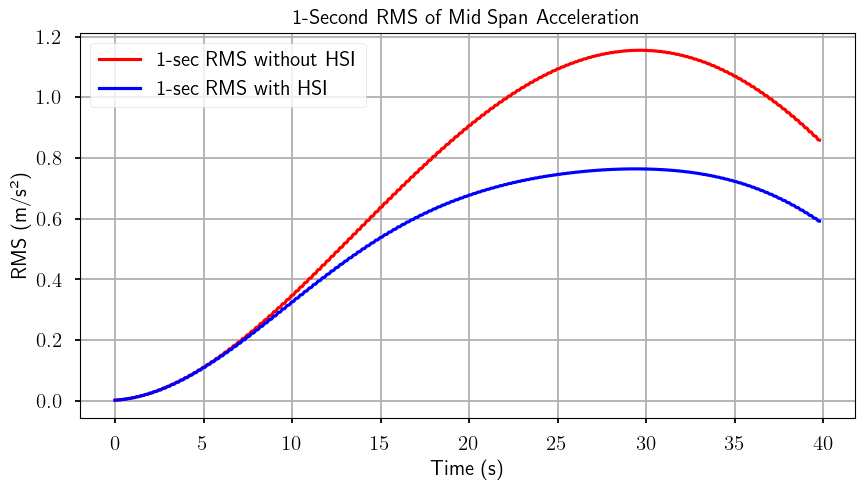

Maximum 1-sec RMS acceleration without HSI: 1.1547924900378541 m/s² at time 29.53 s
Maximum 1-sec RMS acceleration with HSI: 0.7639777994631899 m/s² at time 29.54 s


In [27]:
# Define the window size for 1 second
window_size = int(1 / hht)  # Number of samples in 1 second

# Function to calculate RMS over a sliding window
def calculate_rms(data, window_size):
    rms_values = np.sqrt(np.convolve(data**2, np.ones(window_size), 'valid') / window_size)
    return rms_values

# Calculate 1-second RMS for accn and accn_hsi
rms_accn = calculate_rms(accn, window_size)
rms_accn_hsi = calculate_rms(accn_hsi, window_size)

# Adjust the time array to match the RMS values
t_rms = t[:len(rms_accn)]

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t_rms, rms_accn, label="1-sec RMS without HSI", color='r')
plt.plot(t_rms, rms_accn_hsi, label="1-sec RMS with HSI", color='b')
plt.title("1-Second RMS of Mid Span Acceleration")
plt.xlabel("Time (s)")
plt.ylabel("RMS (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

# Print the maximum RMS values and corresponding times
max_rms_accn = np.max(rms_accn)
max_time_rms_accn = t_rms[np.argmax(rms_accn)]
print(f"Maximum 1-sec RMS acceleration without HSI: {max_rms_accn} m/s² at time {max_time_rms_accn} s")

max_rms_accn_hsi = np.max(rms_accn_hsi)
max_time_rms_accn_hsi = t_rms[np.argmax(rms_accn_hsi)]
print(f"Maximum 1-sec RMS acceleration with HSI: {max_rms_accn_hsi} m/s² at time {max_time_rms_accn_hsi} s")

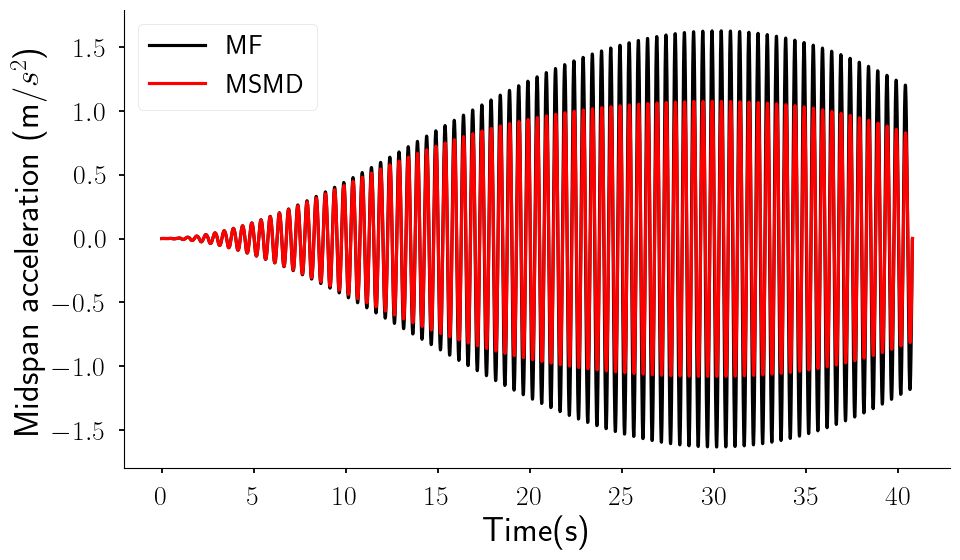

In [40]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)
plt.figure(figsize=(10, 6))
t = np.arange(0, (length+1) / pedvelocity, hht)

plt.plot(t,accn , label ="MF" ,color='black')
plt.plot(t,accn_hsi,label ="MSMD",color='red')
# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent cropping

plt.xlabel("Time(s)")
plt.ylabel("Midspan acceleration (m/$s^2$)")
plt.legend()
plt.tight_layout()
plt.savefig("with and without HSI single pedestrian time history new2.pdf", format='pdf', dpi=300)
plt.show()

In [5]:
import pickle
with open('testipynbHSI.pkl', 'wb') as f:
    pickle.dump(accn_hsi, f)
with open('testipynbNOHSI.pkl', 'wb') as f1:
    pickle.dump(accn, f1)


Maximum acceleration: 0.8279767686168275 m/s² at time 29.79 s with HSI
Maximum acceleration: 0.8278940479683411 m/s² at time 30.03 s with HSI


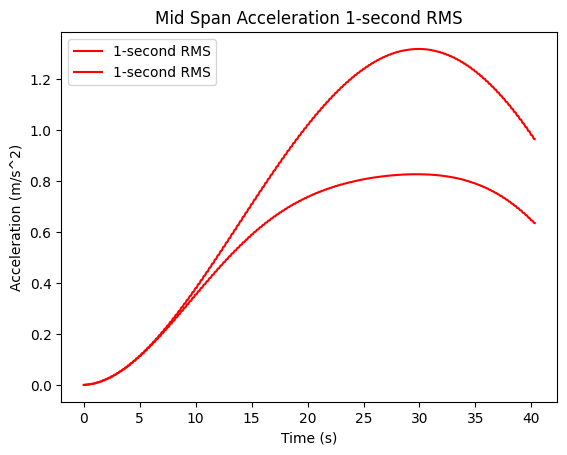

In [5]:
# Define the sampling rate (samples per second)
sampling_rate = 0.5 / (t[1] - t[0])  # Assuming t is uniformly spaced

# Define the window size for 1 second
window_size = int(sampling_rate)

# Calculate the 1-second RMS values
rms_1sHSI = np.array([np.sqrt(np.mean(accn_hsi[i:i + window_size]**2)) for i in range(0, len(accn_hsi) - window_size + 1)])

# Create a time array for the RMS values
rms_timeHSI = t[:len(rms_1sHSI)]


max_index_accnHSI = np.argmax(rms_1sHSI)
# Find the maximum value
max_accnHSI = rms_1sHSI[max_index_accnHSI]
# Find the corresponding time
max_time_accnHSI = rms_timeHSI[max_index_accnHSI]
# Print the results
print(f"Maximum acceleration: {max_accnHSI} m/s² at time {max_time_accnHSI} s with HSI")

# Define the sampling rate (samples per second)
sampling_rate = 0.5 / (t[1] - t[0])  # Assuming t is uniformly spaced

# Define the window size for 1 second
window_size = int(sampling_rate)

# Calculate the 1-second RMS values
rms_1s = np.array([np.sqrt(np.mean(accn[i:i + window_size]**2)) for i in range(0, len(accn) - window_size + 1)])

# Create a time array for the RMS values
rms_time = t[:len(rms_1s)]

max_index_accn = np.argmax(rms_1s)
# Find the maximum value
max_accn = rms_1sHSI[max_index_accn]
# Find the corresponding time
max_time_accn = rms_timeHSI[max_index_accn]
# Print the results
print(f"Maximum acceleration: {max_accn} m/s² at time {max_time_accn} s with HSI")

plt.plot(rms_time, rms_1s, label="1-second RMS", color='r')
plt.plot(rms_timeHSI, rms_1sHSI, label="1-second RMS", color='r')
plt.title("Mid Span Acceleration 1-second RMS")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.show()

max_index_accn = np.argmax(rms_1s)